# 01 Exploration
Template: explore the FlyWire (FAFB) graph. Raw files must be in `data/raw/` (see `data/README.md`).

## Setup

In [1]:
from flybrain.loading import load_graph
from flybrain.viz import plot_class_counts, plot_degree_distribution

c:\Users\maxvo\Desktop\flybrain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\maxvo\Desktop\flybrain\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Load data
Use `synthetic=True` to run without real data.

In [2]:
data = load_graph("super_class", synthetic=False)
data

Data(x=[139255, 6], edge_index=[2, 3732460], y=[139255], edge_weight=[3732460], num_nodes=139255, node_ids=[139255], label_names=[10])

## Class distribution

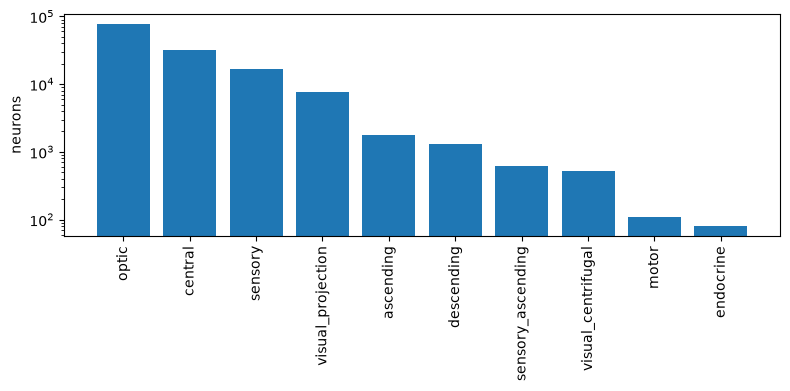

In [3]:
plot_class_counts(data.y.numpy(), data.label_names)

## Degree distribution

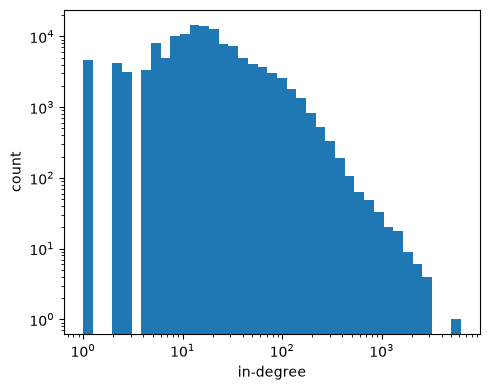

In [4]:
plot_degree_distribution(data.x[:, 0].expm1().numpy(), label="in-degree")

## Tables
Cleaned tables from the Parquet cache (one row per neuron / per pre-post pair, synapses summed).

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from flybrain.loading import CONNECTIONS_STEM, RAW_DIR, find_raw_file, load_tables

neurons, conns = load_tables()
neurons = neurons.set_index("root_id")
neurons["in_degree"] = conns.groupby("post_root_id").size().reindex(neurons.index, fill_value=0)
neurons["out_degree"] = conns.groupby("pre_root_id").size().reindex(neurons.index, fill_value=0)
print(f"{len(neurons):,} neurons, {len(conns):,} connections, {conns.syn_count.sum():,} synapses")

139,255 neurons, 3,732,460 connections, 50,666,648 synapses


## Degree per super class
Degree-only features already separate several classes (sensory: few inputs, motor: few outputs). This is why the logistic-regression baseline is strong.

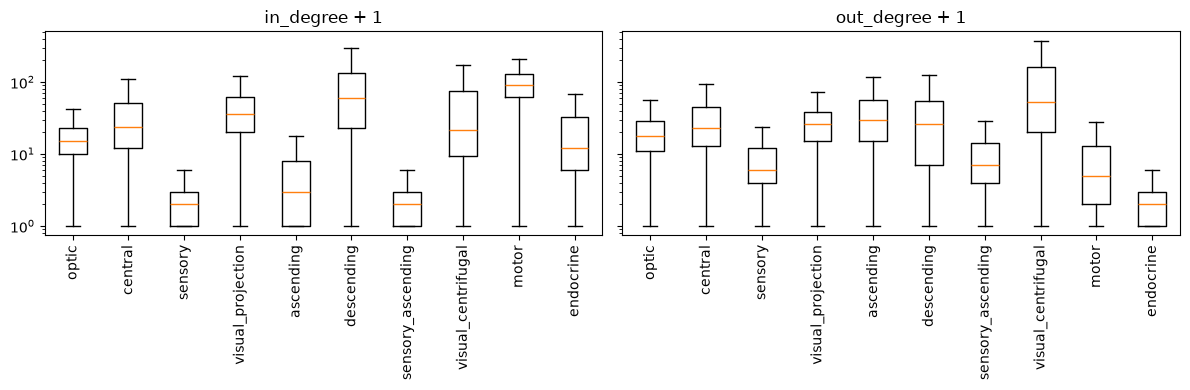

,in_degree,out_degree
super_class,,
optic,14.0,17.0
central,23.0,22.0
sensory,1.0,5.0
visual_projection,35.0,25.0
ascending,2.0,29.0
descending,59.0,25.0
sensory_ascending,1.0,6.0
visual_centrifugal,20.5,52.0
motor,88.5,4.0


In [6]:
order = neurons.super_class.value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col in zip(axes, ["in_degree", "out_degree"], strict=True):
    ax.boxplot([neurons.loc[neurons.super_class == c, col] + 1 for c in order], showfliers=False)
    ax.set_xticks(range(1, len(order) + 1), order, rotation=90)
    ax.set_yscale("log")
    ax.set_title(f"{col} + 1")
plt.tight_layout()
plt.show()
neurons.groupby("super_class")[["in_degree", "out_degree"]].median().loc[order]

## Neurons without connections
Zero-degree neurons are missing from the log-log histogram above.

In [7]:
summary = pd.DataFrame(
    {
        "no_input": neurons.in_degree == 0,
        "no_output": neurons.out_degree == 0,
        "isolated": (neurons.in_degree == 0) & (neurons.out_degree == 0),
    }
)
print(summary.sum())
summary.groupby(neurons.super_class).sum().sort_values("no_input", ascending=False)

no_input     9072
no_output    1737
isolated      671
dtype: int64


,no_input,no_output,isolated
super_class,,,
sensory,7638,489,461
ascending,574,39,34
optic,363,789,61
sensory_ascending,298,51,49
central,150,181,46
visual_projection,20,8,2
descending,16,132,15
endocrine,6,30,0
visual_centrifugal,6,3,2


## Cell types
How many neurons have a `cell_type`, how large are the types, and how many survive a `min_class_size` filter.

In [8]:
sizes = neurons.cell_type.value_counts()
print(
    f"typed neurons: {neurons.cell_type.notna().sum():,} / {len(neurons):,}, types: {len(sizes):,}"
)
pd.DataFrame(
    [
        {
            "min_class_size": m,
            "types": int((sizes >= m).sum()),
            "neurons": int(sizes[sizes >= m].sum()),
        }
        for m in (1, 5, 20, 50, 100)
    ]
).set_index("min_class_size")

typed neurons: 138,327 / 139,255, types: 8,772


,types,neurons
min_class_size,,
1,8772,138327
5,2164,121799
20,434,108647
50,236,102490
100,152,96521


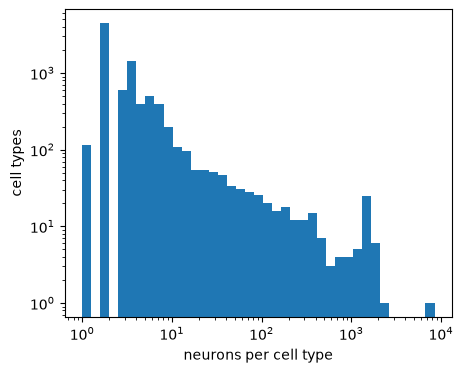

cell_type
R1-6     8456
KCg-m    2189
L1       1775
T2a      1774
Tm3      1756
L2       1728
T4c      1710
T3       1676
KCab     1643
L5       1581
Name: count, dtype: int64

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(sizes, bins=np.logspace(0, np.log10(sizes.max()), 40))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("neurons per cell type")
ax.set_ylabel("cell types")
plt.show()
sizes.head(10)

## Synapses per connection
Codex already drops connections below a synapse threshold (check the minimum).

count    3.732460e+06
mean     1.357460e+01
std      1.910605e+01
min      5.000000e+00
25%      6.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      2.633000e+03
Name: syn_count, dtype: float64


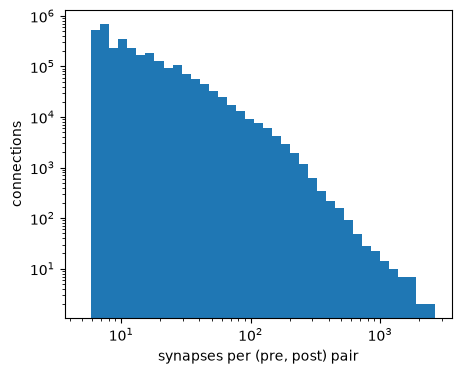

In [10]:
print(conns.syn_count.describe())
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(
    conns.syn_count,
    bins=np.logspace(np.log10(conns.syn_count.min()), np.log10(conns.syn_count.max()), 40),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("synapses per (pre, post) pair")
ax.set_ylabel("connections")
plt.show()

## Connectivity between super classes
Fraction of each class's output synapses that go to each target class (rows sum to 1).

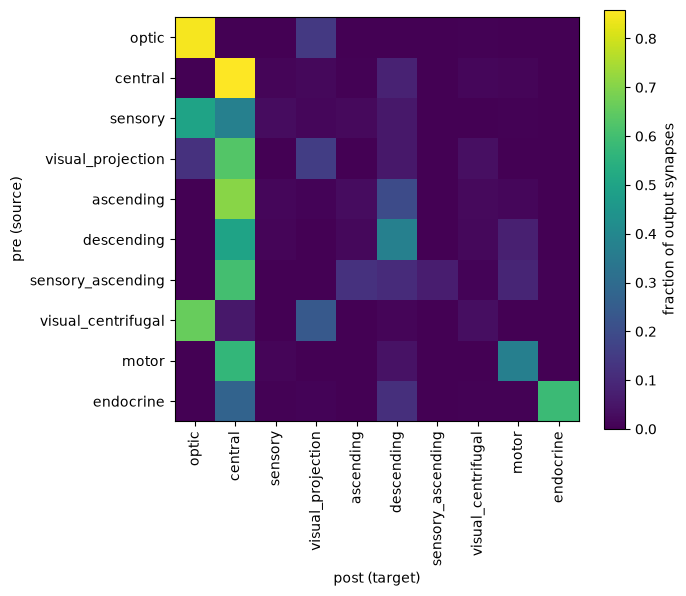

In [11]:
sc = neurons.super_class
m = conns.assign(
    pre=sc.reindex(conns.pre_root_id).to_numpy(), post=sc.reindex(conns.post_root_id).to_numpy()
)
mat = m.pivot_table(index="pre", columns="post", values="syn_count", aggfunc="sum", fill_value=0)
mat = mat.reindex(index=order, columns=order, fill_value=0)
frac = mat.div(mat.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(frac, cmap="viridis")
ax.set_xticks(range(len(order)), order, rotation=90)
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("post (target)")
ax.set_ylabel("pre (source)")
fig.colorbar(im, label="fraction of output synapses")
plt.tight_layout()
plt.show()

## Further annotations (optional)
Other columns in `classification` that could serve as features or labels, and neurotransmitter predictions from the raw connections file (slow: reads the full file).

In [12]:
for col in ["flow", "class", "side", "hemilineage", "nerve"]:
    if col in neurons:
        print(f"{col}: {neurons[col].nunique()} values, {neurons[col].isna().mean():.0%} missing")

flow: 3 values, 0% missing
class: 29 values, 23% missing
side: 3 values, 0% missing
hemilineage: 214 values, 73% missing
nerve: 8 values, 93% missing


In [13]:
raw = pd.read_csv(find_raw_file(RAW_DIR, CONNECTIONS_STEM), usecols=["syn_count", "nt_type"])
raw.groupby("nt_type").syn_count.sum().sort_values(ascending=False) / raw.syn_count.sum()

nt_type
ACH     0.594106
GABA    0.234917
GLUT    0.150546
SER     0.009909
DA      0.007474
OCT     0.003048
Name: syn_count, dtype: float64

## Notes